In [22]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
pip install ollama

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import pandas as pd

In [25]:
import seaborn as sns

In [26]:
import matplotlib.pyplot as plt

In [27]:
url = r"C:\Users\DELL\Downloads\titanic_ dataset_final.csv"

In [28]:
df = pd.read_csv(url)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\DELL\\Downloads\\titanic_ dataset_final.csv'

In [29]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [30]:
print(df.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


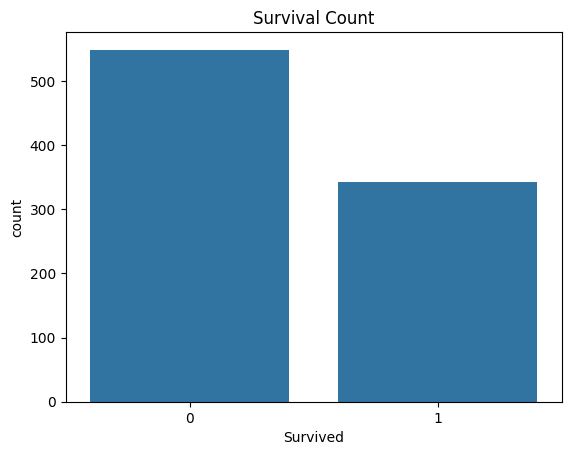

In [33]:
# survival rate visualization
sns.countplot(x='Survived', data = df)
plt.title("Survival Count")
plt.show() # not survived  rate is more 

In [34]:
import ollama 

def generate_insights(df_summary):
    prompt = f"Analyze the dataset summary and provide insights:\n\n{df_summary}"
    response = ollama.chat(model = "mistral",messages=[{"role": "user", "content":prompt}])
    return response ['message']['content']

# Generate Ai insights
summary = df.describe().to_string()
insights = generate_insights(summary)
print("\n Ai Generated Insights :\n" , insights)


 Ai Generated Insights :
  The dataset summary provided is from the Titanic data, a well-known dataset in machine learning and data science. Here are some insights based on the summary:

1. **Number of Passengers**: There are 891 unique passengers in the dataset.

2. **Survival Status**: Approximately 38.4% of passengers survived, while 61.6% did not survive.

3. **Passenger Class**: The most common class was second class (Pclass=2), with a mean of 2.308642, followed by first class (Pclass=1) and third class (Pclass=3).

4. **Age Distribution**: The average age is 29.7 years old, with the youngest passenger being 0.42 years old and the oldest being 80 years old. There is a wide variation in ages, as evidenced by the high standard deviation of 14.53 years.

5. **Family Size**: On average, each passenger had 0.52 siblings aboard (SibSp) and 0.38 parents or children (Parch). This suggests that many passengers were traveling alone.

6. **Fare**: The mean fare is $32.20, with a wide range 

In [35]:
import gradio as gr

def eda_analysis(file):
    df = pd.read_csv(file.name)
    summary = df.describe().to_string()
    insights = generate_insights(summary)
    return insights

# Create Web Interface
demo = gr.Interface(fn=eda_analysis, inputs="file", outputs="text", title="AI-Powered EDA with Mistral")

# Launch App
demo.launch(share=True)  # Use share=True for Google Colab


* Running on local URL:  http://127.0.0.1:7861


OSError: [WinError 225] Operation did not complete successfully because the file contains a virus or potentially unwanted software: 'C:\\Users\\DELL\\.cache\\huggingface\\gradio\\frpc\\frpc_windows_amd64_v0.3'

Traceback (most recent call last):
  File "c:\Users\DELL\anaconda3\Lib\site-packages\gradio\queueing.py", line 667, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File "c:\Users\DELL\anaconda3\Lib\site-packages\gradio\route_utils.py", line 349, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<11 lines>...
    )
    ^
  File "c:\Users\DELL\anaconda3\Lib\site-packages\gradio\blocks.py", line 2274, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<8 lines>...
    )
    ^
  File "c:\Users\DELL\anaconda3\Lib\site-packages\gradio\blocks.py", line 1781, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        fn, *processed_input, limiter=self.limiter
        ^^^^^^